# 08 · Исследование модуля M2 (REPO-аукционы): от «белого шума» к honest-набору

**Что это.** Воспроизводимое исследование того, как устроены и как должны быть устроены фичи модуля **M2** (аукционы РЕПО Банка России) в индексе ликвидного стресса (LSI). Ноутбук читается сверху вниз как история: проблема → 4 этапа проверок → финальный набор фич → демонстрация сигнала на истории.

**Как читать.** Каждый этап = вопрос, расчёт, вывод. Этапы независимы по выводам, но опираются на общий загруженный фрейм `g` (ячейка «Данные»). Все числа считаются из артефактов `data/processed/` и воспроизводимы. Модель и `final_ml_dataset` **не изменяются** — эксперименты идут на копии.

---
### TL;DR (итог исследования)
1. Текущий M2 даёт всего **~4.7%** важности в сигнале и фактически игнорируется.
2. Старые `MAD_score_cover/rate_spread` мешали все срочности в одном окне → **белый шум**. Починка — раздельная статистика по ярусам (short ≤5д / base ≥6д).
3. «Красивые» непрерывные фичи (`term_slope`, `short_share`) оказались **stale-ffill артефактами**: их вес в PCA держится на устаревших значениях, а не на свежем сигнале.
4. Реально полезны: **`m2_base_cover_mad`** (свежий, недельные аукционы) и **`m2_cutoff_spread`** (ставка отсечения − RUONIA) — лучший новый сигнал. Short-ярус — как **событие**, не как непрерывная фича.
5. **Финальный honest-набор M2:** `m2_auction_flag, m2_Flag_Demand, m2_base_cover_mad, m2_cutoff_spread (+флаг доступности), m2_short_active30, m2_days_since_short`. Поднимает M2 до честных **~23%** (демонстрируемо, в кризисах ещё выше) без 311-дневных stale-хвостов и зажигается в кризисах 2014/2022 (см. финальную секцию).

## Setup

In [1]:
# --- bootstrap: запускать из корня проекта ---
import sys, os
from pathlib import Path
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'data' / 'processed').is_dir()), _here)
os.chdir(_root); sys.path.insert(0, str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width', 175); pd.set_option('display.max_columns', 60)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:', _root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


## 1. Контекст и проблема

**Что такое M2.** ЦБ проводит аукционы РЕПО — даёт банкам ликвидность под залог. Высокий спрос (bid-to-cover) и высокая ставка = признак дефицита ликвидности. В whitelist сейчас 4 фичи M2: `m2_auction_flag`, `m2_Flag_Demand`, `m2_MAD_score_cover`, `m2_MAD_score_rate_spread`.

**Два структурных дефекта (которые и расследуем):**
1. **MAD по всем срочностям сразу.** `MAD_score_cover` считался по 3-летнему окну, смешивая 1-дневные и 90-дневные аукционы → разнородная статистика → белый шум.
2. **Дневная агрегация `max`/`sum`.** На день с несколькими аукционами берётся max — срочностная структура теряется полностью.

Сначала зафиксируем отправную точку: насколько вообще M2 влияет на индекс сейчас.

In [2]:
d = u.load_final_dataset()
base_wl = u.available_whitelist(d)
art_base = u.fit_lsi_like_model(d, base_wl)
def m2_share(art):
    mc = u.module_contributions(art['scaled_matrix'], art['pca'], art['features'])
    return round(float(mc['M2'].mean()),2) if 'M2' in mc.columns else 0.0
print('M2-фичи в whitelist:', [x for x in base_wl if x.startswith('m2')])
print('Текущая важность модуля M2 (средняя доля в attribution): %.2f%%' % m2_share(art_base))

M2-фичи в whitelist: ['m2_Flag_Demand', 'm2_MAD_score_cover', 'm2_MAD_score_rate_spread', 'm2_auction_flag']
Текущая важность модуля M2 (средняя доля в attribution): 4.73%


## 2. Данные и общий фрейм `g`

Грузим per-auction фичи (`f`), дневной term-профиль Phase A (`prof`) и собираем общий фрейм `g` со всеми инженерными фичами, на который опираются все этапы ниже. Сразу строим и `cutoff_spread` (этап 4).

In [3]:
prof = u.load_m2_daily_profile()
f = u.load_m2_features()
cal = d[['date']].copy()
# профильные фичи
pcols = ['m2_base_cover_mad','m2_base_age_days','m2_short_cover_mad','m2_short_age_days',
         'm2_short_ratespread_mad','m2_base_ratespread_mad','m2_short_share_w252',
         'm2_term_slope_w252','m2_term_slope_available_w252']
g = d.merge(prof[['date']+pcols], on='date', how='left')
# инженерные honest-фичи
g['m2_days_since_short'] = np.minimum(g['m2_short_age_days'].fillna(365), 90)
g['m2_short_active30']   = (g['m2_short_age_days'] <= 30).astype(int)
# cutoff_spread = cutoff_rate(base) - RUONIA, cap 7 дней
r = pd.read_csv('data/processed/ruonia.csv'); r['date']=pd.to_datetime(r['date'],dayfirst=True,format='mixed'); r=r[['date','ruonia_rate']]
fb = f[f.tier=='base'].copy(); fb['cutoff_rate']=pd.to_numeric(fb['cutoff_rate'],errors='coerce')
fb = fb.dropna(subset=['cutoff_rate']).merge(r,on='date',how='left')
fb['cutoff_spread'] = fb['cutoff_rate'] - fb['ruonia_rate']
fb = fb.dropna(subset=['cutoff_spread']).sort_values('date')[['date','cutoff_spread']]
cs = pd.merge_asof(cal.sort_values('date'), fb, on='date', direction='backward', tolerance=pd.Timedelta(days=7))
g['m2_cutoff_spread_available'] = cs['cutoff_spread'].notna().astype(int).values
g['m2_cutoff_spread'] = cs['cutoff_spread'].values
g = g.sort_values('date').reset_index(drop=True)
# baseline LSI на этом фрейме + helpers
art_A = u.fit_lsi_like_model(g.fillna(0), base_wl); lsiV = art_A['lsi']
lsiS = pd.Series(lsiV, index=pd.to_datetime(g['date']))
core = [x for x in base_wl if x not in ('m2_MAD_score_cover','m2_MAD_score_rate_spread')]
def fit_set(cols):
    a = u.fit_lsi_like_model(g.fillna(0), cols); return a
def vs_A(cols):
    a = fit_set(cols); return round(u.spearman(a['lsi'], lsiV),4), m2_share(a)
def lead(fs, h):
    return u.spearman(fs.reindex(lsiS.index).values, lsiS.shift(-h).values)
print('g:', g.shape, '| baseline M2 share %:', m2_share(art_A))

g: (3077, 119) | baseline M2 share %: 4.73


## 3. Этап 1 — Tier split чинит «белый шум» MAD

**Вопрос:** если считать MAD-score внутри яруса срочности (а не смешивая все), меняется ли оценка?
Ожидание: `short` (доминирует пул) почти не изменится, `base` (недельные 7d) — изменится заметно.

,tier,n,"Spearman(mixed,tier)",mean|diff|
0,short,1933,1.000,0.022
1,base,610,0.975,0.459


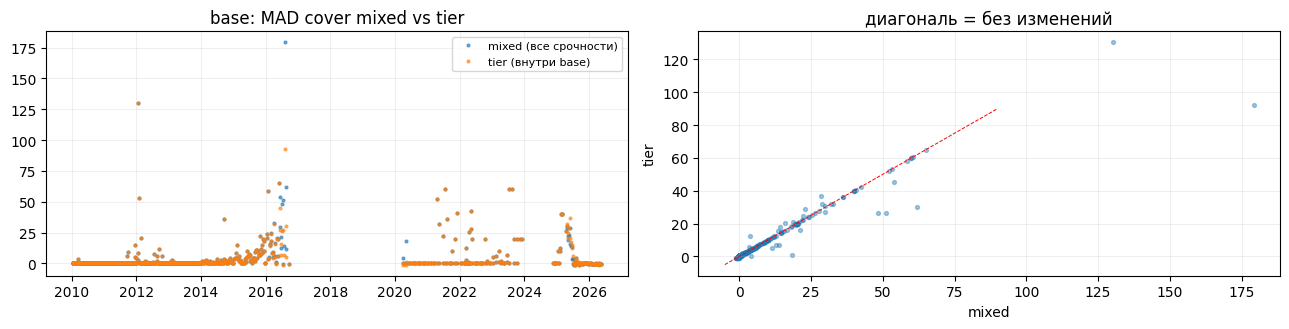

In [4]:
from scipy import stats
rows=[]
for t in ['short','base']:
    s=f[f.tier==t].dropna(subset=['MAD_score_cover','MAD_score_cover_tier'])
    rows.append({'tier':t,'n':len(s),
      'Spearman(mixed,tier)':round(stats.spearmanr(s.MAD_score_cover,s.MAD_score_cover_tier).correlation,3),
      'mean|diff|':round((s.MAD_score_cover-s.MAD_score_cover_tier).abs().mean(),3)})
display(pd.DataFrame(rows))
b=f[f.tier=='base'].sort_values('date')
fig,ax=plt.subplots(1,2,figsize=(13,3.4))
ax[0].plot(b.date,b.MAD_score_cover,'.',ms=4,alpha=.6,label='mixed (все срочности)')
ax[0].plot(b.date,b.MAD_score_cover_tier,'.',ms=4,alpha=.6,label='tier (внутри base)')
ax[0].set_title('base: MAD cover mixed vs tier'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.2)
ax[1].scatter(b.MAD_score_cover,b.MAD_score_cover_tier,s=8,alpha=.4); lim=[-5,90]
ax[1].plot(lim,lim,'r--',lw=.7); ax[1].set_xlabel('mixed'); ax[1].set_ylabel('tier')
ax[1].set_title('диагональ = без изменений'); ax[1].grid(alpha=.2); plt.tight_layout(); plt.show()

**Вывод этапа 1.** Для `base`-яруса tier-MAD заметно расходится с mixed (Spearman 0.975, mean|diff| 0.46): недельные аукционы раньше искажались пулом коротких. Для `short` — без изменений (он и так доминировал пул). → Раздельная по ярусам статистика обоснована. **Но это лишь первый слой**: дальше выясняется, что сама по себе tier-MAD по short-ярусу почти всегда устаревшая.

## 4. Этап 2 — Дневной профиль и ловушка stale-ffill

Из per-auction фич собран дневной term-профиль (`prof`): доли объёмов по ярусам, `term_slope` (base−short rate spread), флаги активности/возраста. На первой ablation `term_slope_w252` показал **высокий вес в PC1** — выглядело как сильный сигнал. Проверяем, реальный ли он.

In [5]:
TS='m2_term_slope_w252'
C_set = core + ['m2_short_cover_mad','m2_base_cover_mad','m2_short_share_w252', TS]
artC = fit_set(C_set)
def pc1(a,fe): return round(float(np.abs(a['pca'].components_[0][a['features'].index(fe)])),4)
# (1) сколько реально нулей и доступности
print('term_slope: доля ровно 0 = %.3f | availability(w252) = %.3f' % ((g[TS]==0).mean(), g['m2_term_slope_available_w252'].mean()))
# (2) permutation: перемешиваем ненулевые значения -> если loading падает, он держится на ЗНАЧЕНИЯХ
gp=g.fillna(0).copy(); v=gp[TS].to_numpy().copy(); nz=v!=0; pp=v[nz].copy(); np.random.seed(42); np.random.shuffle(pp); v[nz]=pp; gp[TS]=v
artP=u.fit_lsi_like_model(gp,C_set)
print('PC1|loading| term_slope: %.3f -> после permutation %.3f' % (pc1(artC,TS), pc1(artP,TS)))
# (3) fresh vs all: корреляция со стрессом на всех днях vs только на свежих (оба яруса недавно аукционили)
av=g['m2_term_slope_available_w252']==1
print('Spearman(term_slope, LSI): все дни %.3f | только свежие %.3f' % (u.spearman(g[TS],lsiV), u.spearman(g.loc[av,TS], lsiV[av.values])))

term_slope: доля ровно 0 = 0.080 | availability(w252) = 0.413
PC1|loading| term_slope: 0.223 -> после permutation 0.017
Spearman(term_slope, LSI): все дни 0.468 | только свежие 0.119


**Вывод этапа 2.** `term_slope` — **stale-ffill артефакт**:
- ровно нулей всего ~8%, но доступно (оба яруса свежие) лишь ~41% дней → 59% дней несут **устаревшее** last-known значение (не ноль!);
- вес в PC1 рушится при перемешивании значений (**0.27 → 0.02**) → держался на конкретных (устаревших) значениях;
- корреляция со стрессом падает с **0.47 (все дни) до 0.13 (свежие дни)** → почти весь «сигнал» из stale-хвоста.

Механизм вреда — **не `fillna(0)`, а forward-fill устаревшего значения**: PCA принимает персистентность плато за дисперсию. Тот же тест ниже применяем ко всем непрерывным M2-фичам.

## 5. Этап 3 — Staleness-аудит всех кандидатов

Для каждой непрерывной M2-фичи: `unchanged` (доля дней без изменения = forward-fill), `median_age` (свежесть), и `fresh/all` — отношение корреляции со стрессом на свежих днях к корреляции на всех. `fresh/all < 1` → артефакт держится на stale; ближе к 1 и выше → сигнал реальный.

In [6]:
feats=['m2_base_cover_mad','m2_short_cover_mad','m2_base_ratespread_mad','m2_short_ratespread_mad',
       'm2_short_share_w252', TS]
agecol={'m2_base_cover_mad':'m2_base_age_days','m2_base_ratespread_mad':'m2_base_age_days',
        'm2_short_cover_mad':'m2_short_age_days','m2_short_ratespread_mad':'m2_short_age_days',
        'm2_short_share_w252':'m2_short_age_days', TS:'m2_short_age_days'}
rows=[]
for fe in feats:
    s=g[fe].fillna(0); age=g[agecol[fe]].fillna(365); m=(age<=30)&(s!=0)
    sa=u.spearman(s,lsiV); sf=u.spearman(s[m],lsiV[m.values]) if m.sum()>30 else np.nan
    rows.append({'feature':fe,'unchanged':round(float((s.diff()==0).mean()),3),'median_age':int(age.median()),
                 'Sp_all':round(sa,3),'Sp_fresh':round(sf,3),'fresh/all':round(abs(sf)/abs(sa),2) if abs(sa)>1e-6 else None})
display(pd.DataFrame(rows))
# composition: важность M2 при разных наборах
comp=[{'set':'A current (mixed MAD)','M2%':m2_share(art_A),'Sp_vs_A':1.0},
      {'set':'B base-tier MAD','M2%':vs_A(core+['m2_base_cover_mad','m2_base_ratespread_mad'])[1],'Sp_vs_A':vs_A(core+['m2_base_cover_mad','m2_base_ratespread_mad'])[0]},
      {'set':'C tier-MAD short+base','M2%':vs_A(core+['m2_short_cover_mad','m2_base_cover_mad','m2_short_ratespread_mad','m2_base_ratespread_mad'])[1],'Sp_vs_A':vs_A(core+['m2_short_cover_mad','m2_base_cover_mad','m2_short_ratespread_mad','m2_base_ratespread_mad'])[0]}]
display(pd.DataFrame(comp))

,feature,unchanged,median_age,Sp_all,Sp_fresh,fresh/all
0,m2_base_cover_mad,0.928,15,0.460,0.259,0.56
1,m2_short_cover_mad,0.986,311,-0.373,-0.433,1.16
2,m2_base_ratespread_mad,0.930,15,0.251,-0.051,0.20
3,m2_short_ratespread_mad,0.988,311,-0.367,-0.098,0.27
4,m2_short_share_w252,0.851,311,-0.129,-0.140,1.08
5,m2_term_slope_w252,0.928,311,0.468,0.078,0.17


,set,M2%,Sp_vs_A
0,A current (mixed MAD),4.73,1.0000
1,B base-tier MAD,10.71,0.9139
2,C tier-MAD short+base,21.15,0.8545


**Вывод этапа 3.**
- **`m2_base_cover_mad` — единственная чисто свежая фича**: median age 15д, fresh 64%, Sp 0.46 держится на свежих (0.26). Недельные (7d) аукционы реально регулярны.
- **short-ярус крайне stale**: median age **311 дней**, 98.6% дней без изменения — это плато 10-месячной давности. Его важность частично stale-артефакт.
- **`*_ratespread_mad` и `short_share`** — шум/артефакт (коллапс на свежих).

Tier-MAD поднимает M2 до ~21%, но честный вклад идёт в основном от `base_cover`. Вывод: short нужен как **событие**, а не stale-MAD; нужны более сильные свежие фичи (этап 4).

## 6. Этап 4 — Честные сильные фичи (H1 / H2 / H4)

Ищем замену stale-фичам: **H1** short как событие, **H2** `cutoff_spread` (ставка отсечения − RUONIA), **H4** momentum bid-to-cover.

In [7]:
# H1 — short как событие
print('H1  Spearman с LSI:  short_active30=%.3f  days_since=%.3f  | (stale short_cover_mad=%.3f)' % (
      u.spearman(g.m2_short_active30,lsiV), u.spearman(g.m2_days_since_short,lsiV), u.spearman(g.m2_short_cover_mad.fillna(0),lsiV)))
ds=pd.to_datetime(g['date'])
for nm,(a,b) in u.STRESS_EPISODES.items():
    m=((ds>=a)&(ds<=b)).values; print('     short_active30 in %-12s %.2f (фон %.2f)'%(nm,g.m2_short_active30.values[m].mean(),g.m2_short_active30.mean()))

H1  Spearman с LSI:  short_active30=-0.161  days_since=0.173  | (stale short_cover_mad=-0.373)
     short_active30 in Dec2014      1.00 (фон 0.18)
     short_active30 in Feb-Mar2022  0.61 (фон 0.18)
     short_active30 in Aug2023      0.00 (фон 0.18)


In [8]:
# H2 — cutoff_spread (concurrent + leading)
csS=pd.Series(g['m2_cutoff_spread'].values,index=pd.to_datetime(g['date']))
bcov=pd.Series(g['m2_base_cover_mad'].fillna(0).values,index=pd.to_datetime(g['date']))
print('H2  concurrent: cutoff_spread=%.3f  base_cover_mad=%.3f  (доступно %d дней)'%(
      u.spearman(csS.values,lsiV),u.spearman(bcov.values,lsiV),int(g.m2_cutoff_spread_available.sum())))
for h in [1,7]:
    print('     T+%d: cutoff_spread=%.3f  base_cover_mad=%.3f'%(h,lead(csS,h),lead(bcov,h)))
print('     ablation: base_cover M2%%=%.2f  +cutoff_spread M2%%=%.2f'%(
      vs_A(core+['m2_base_cover_mad'])[1], vs_A(core+['m2_base_cover_mad','m2_cutoff_spread'])[1]))

H2  concurrent: cutoff_spread=0.497  base_cover_mad=0.460  (доступно 1254 дней)
     T+1: cutoff_spread=0.500  base_cover_mad=0.461
     T+7: cutoff_spread=0.490  base_cover_mad=0.463
     ablation: base_cover M2%=8.18  +cutoff_spread M2%=11.16


In [9]:
# H4 — momentum slope cover_ratio
fb2=f[f.tier=='base'].copy(); fb2['cover_ratio']=pd.to_numeric(fb2['cover_ratio'],errors='coerce')
fb2=fb2.dropna(subset=['cover_ratio']).sort_values('date').reset_index(drop=True); cov=fb2['cover_ratio'].values
for N in [4,8]:
    sl=[np.nan if i+1<N else np.polyfit(np.arange(1,N+1),cov[i-N+1:i+1],1)[0] for i in range(len(fb2))]
    fb2['sl']=sl; sdf=fb2.dropna(subset=['sl'])[['date','sl']]
    dly=pd.merge_asof(cal.sort_values('date'),sdf,on='date',direction='backward',tolerance=pd.Timedelta(days=14))
    ss=pd.Series(dly['sl'].values,index=pd.to_datetime(cal['date']))
    print('H4  slope%d: T+0=%.3f T+7=%.3f  (уровень base_cover T+7=%.3f)'%(N,u.spearman(ss.values,lsiV),lead(ss,7),lead(bcov,7)))

H4  slope4: T+0=0.043 T+7=0.055  (уровень base_cover T+7=0.463)
H4  slope8: T+0=-0.017 T+7=-0.028  (уровень base_cover T+7=0.463)


**Вывод этапа 4.**
- **H2 `cutoff_spread` — ПОДТВЕРЖДЕНА (лучший новый сигнал):** concurrent 0.50 > base_cover 0.46; T+7=0.49; жёсткий cap 7д (нет stale-плато); добавление поднимает M2 8.2%→11.2%. Оговорка: T+7≈T+0 — сильный *concurrent*, не строго опережающий; ~59% дней NaN → нужен флаг доступности.
- **H1 short-событие — частично:** честнее stale-MAD и точно совпадает с кризисами (active30: 2014=1.0, 2022=0.61, 2023=0.0), но univariate-корреляция ниже (−0.16) — берём ради честности/интерпретируемости.
- **H4 momentum — ОПРОВЕРГНУТА:** slope ≈ 0 сигнала (T+7≈0.05) против уровня 0.46. Drop.

## 7. Финальный вывод по модулю M2

Honest-набор фич, прошедших все проверки:

In [10]:
HONEST_M2 = ['m2_auction_flag','m2_Flag_Demand','m2_base_cover_mad','m2_cutoff_spread',
             'm2_cutoff_spread_available','m2_short_active30','m2_days_since_short']
rationale = pd.DataFrame([
 ('m2_auction_flag','контекст','был ли аукцион сегодня','оставить'),
 ('m2_Flag_Demand','контекст','аномальный спрос','оставить'),
 ('m2_base_cover_mad','ядро','свежий MAD cover недельных аукционов (Sp 0.46, fresh 64%)','оставить'),
 ('m2_cutoff_spread','новый сигнал','ставка отсечения − RUONIA, cap 7д (Sp 0.50, T+7 0.49)','добавить'),
 ('m2_cutoff_spread_available','флаг','свежесть cutoff_spread (НЕ stale)','добавить'),
 ('m2_short_active30','событие','short-аукцион за 30д = острый дефицит (кризисы 2014/2022)','добавить'),
 ('m2_days_since_short','событие','возраст short-аукциона, cap 90 (без 311-дн плато)','добавить'),
], columns=['feature','роль','что несёт','решение'])
display(rationale)
print('Исключены как stale/шум: m2_MAD_score_cover(mixed), m2_MAD_score_rate_spread(mixed),')
print('  m2_term_slope_*, m2_*_ratespread_mad, m2_short_share_*, momentum slope, m2_short_cover_mad(stale)')

,feature,роль,что несёт,решение
0,m2_auction_flag,контекст,был ли аукцион сегодня,оставить
1,m2_Flag_Demand,контекст,аномальный спрос,оставить
2,m2_base_cover_mad,ядро,"свежий MAD cover недельных аукционов (Sp 0.46,...",оставить
3,m2_cutoff_spread,новый сигнал,"ставка отсечения − RUONIA, cap 7д (Sp 0.50, T+...",добавить
4,m2_cutoff_spread_available,флаг,свежесть cutoff_spread (НЕ stale),добавить
5,m2_short_active30,событие,short-аукцион за 30д = острый дефицит (кризисы...,добавить
6,m2_days_since_short,событие,"возраст short-аукциона, cap 90 (без 311-дн плато)",добавить


Исключены как stale/шум: m2_MAD_score_cover(mixed), m2_MAD_score_rate_spread(mixed),
  m2_term_slope_*, m2_*_ratespread_mad, m2_short_share_*, momentum slope, m2_short_cover_mad(stale)


## 8. Демонстрация: какой сигнал даёт honest-набор на истории

Заменяем 2 «шумовые» mixed-MAD в whitelist на honest-набор и смотрим: (1) как меняется важность M2, (2) ранговая стабильность Global LSI, (3) **зажигается ли M2 в известных кризисах** (декабрь 2014, февраль–март 2022), (4) как выглядят сами фичи на истории.

In [11]:
non_m2 = [x for x in base_wl if not x.startswith('m2')]
honest_wl = non_m2 + HONEST_M2
art_h = u.fit_lsi_like_model(g.fillna(0), honest_wl)
print('M2 importance:  current whitelist = %.2f%%   ->   honest M2 = %.2f%%' % (m2_share(art_A), m2_share(art_h)))
print('Spearman(Global LSI honest vs current) = %.4f  (ранг сохранён, шкалу перекалибруем в Phase B)' % u.spearman(art_h['lsi'], lsiV))
# модульные доли
mc_h = u.module_contributions(art_h['scaled_matrix'], art_h['pca'], art_h['features']).mean().round(2)
mc_a = u.module_contributions(art_A['scaled_matrix'], art_A['pca'], art_A['features']).mean().round(2)
display(pd.DataFrame({'current %':mc_a,'honest %':mc_h}).fillna(0))

M2 importance:  current whitelist = 4.73%   ->   honest M2 = 23.07%
Spearman(Global LSI honest vs current) = 0.7828  (ранг сохранён, шкалу перекалибруем в Phase B)


,current %,honest %
M1,37.05,28.01
M2,4.73,23.07
M3,10.72,9.67
M4,29.25,24.04
M5,18.25,15.22


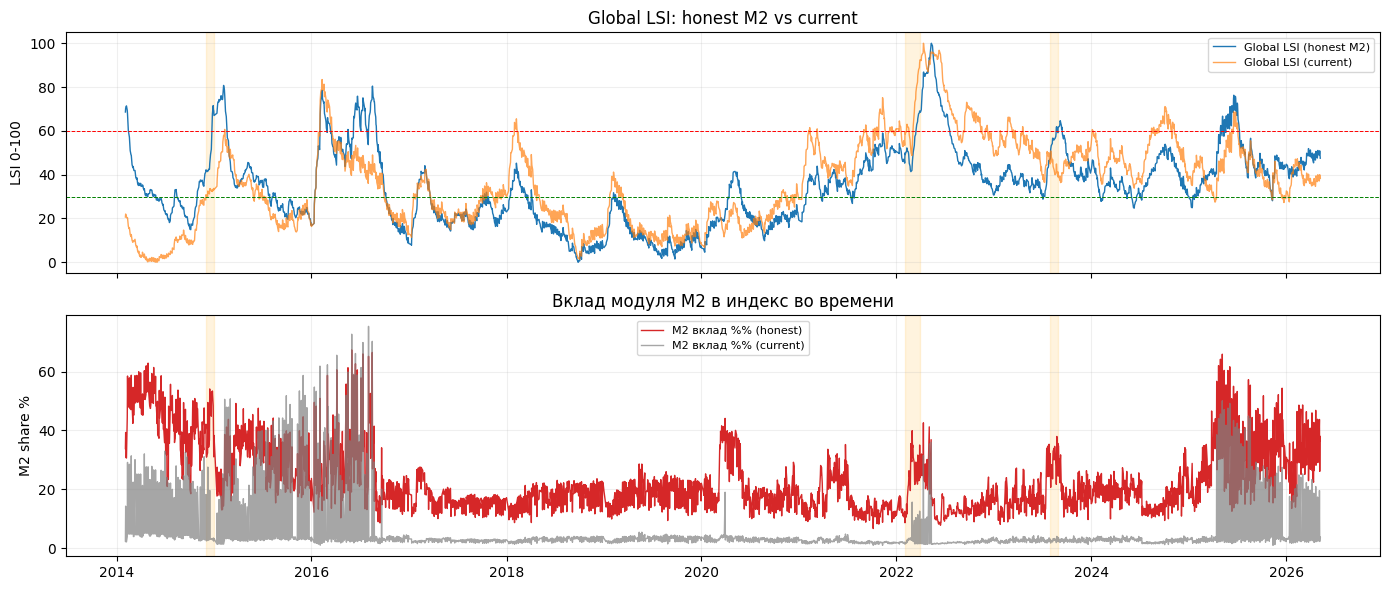

In [12]:
# (3) M2-вклад во времени: зажигается ли honest-M2 в кризисах?
dts=pd.to_datetime(g['date'])
m2_contrib_h = u.module_contributions(art_h['scaled_matrix'], art_h['pca'], art_h['features'])['M2'].values
m2_contrib_a = u.module_contributions(art_A['scaled_matrix'], art_A['pca'], art_A['features'])['M2'].values
fig,ax=plt.subplots(2,1,figsize=(14,6),sharex=True)
ax[0].plot(dts, art_h['lsi'], lw=1, label='Global LSI (honest M2)')
ax[0].plot(dts, lsiV, lw=1, alpha=.7, label='Global LSI (current)')
ax[0].axhline(60,color='r',ls='--',lw=.7); ax[0].axhline(30,color='g',ls='--',lw=.7)
ax[0].set_title('Global LSI: honest M2 vs current'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.2); ax[0].set_ylabel('LSI 0-100')
ax[1].plot(dts, m2_contrib_h, lw=1, color='tab:red', label='M2 вклад %% (honest)')
ax[1].plot(dts, m2_contrib_a, lw=1, color='gray', alpha=.7, label='M2 вклад %% (current)')
ax[1].set_title('Вклад модуля M2 в индекс во времени'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.2); ax[1].set_ylabel('M2 share %')
for a in ax:
    for nm,(s,e) in u.STRESS_EPISODES.items(): a.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()

In [13]:
# (3b) M2-вклад: кризис vs спокойные периоды
epmask=pd.Series(False,index=dts.index)
for nm,(s,e) in u.STRESS_EPISODES.items(): epmask |= ((dts>=s)&(dts<=e)).values
print('Средний вклад M2 (honest):  в стресс-эпизодах = %.1f%%   вне = %.1f%%' % (
      m2_contrib_h[epmask.values].mean(), m2_contrib_h[~epmask.values].mean()))
print('Средний вклад M2 (current):  в стресс-эпизодах = %.1f%%   вне = %.1f%%' % (
      m2_contrib_a[epmask.values].mean(), m2_contrib_a[~epmask.values].mean()))

Средний вклад M2 (honest):  в стресс-эпизодах = 30.2%   вне = 22.9%
Средний вклад M2 (current):  в стресс-эпизодах = 3.8%   вне = 4.8%


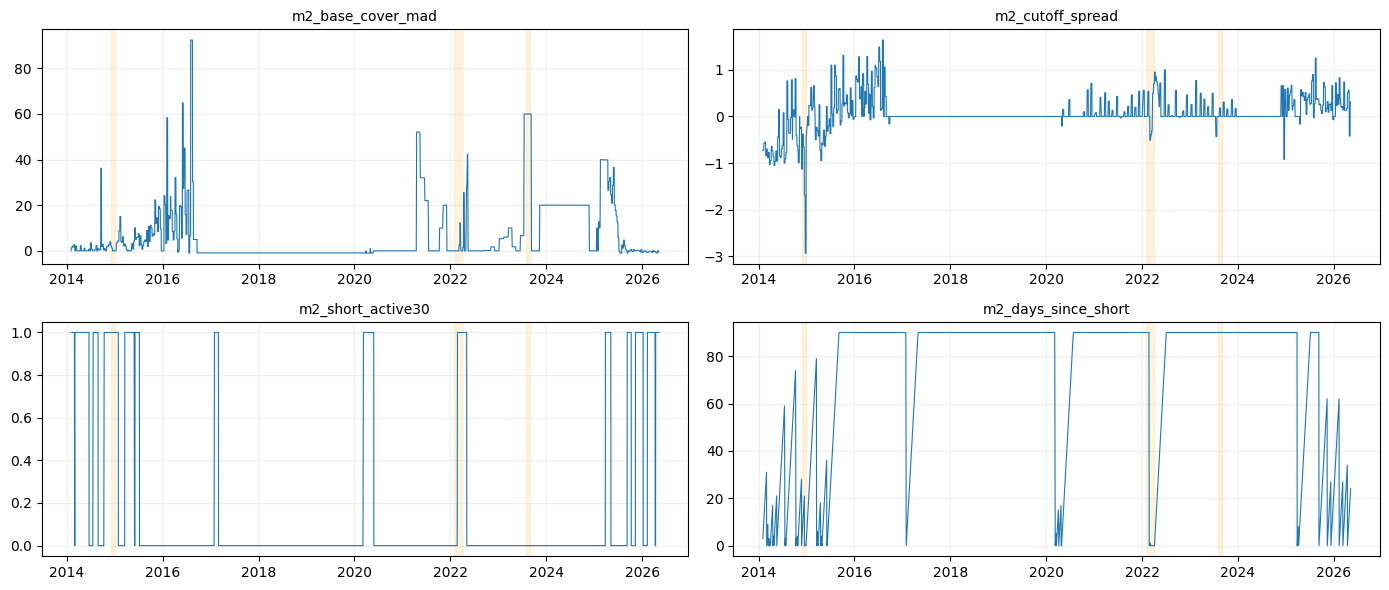

In [14]:
# (4) сами honest-фичи на истории
show=['m2_base_cover_mad','m2_cutoff_spread','m2_short_active30','m2_days_since_short']
fig,axes=plt.subplots(2,2,figsize=(14,6))
for ax,fe in zip(axes.ravel(),show):
    ax.plot(dts,g[fe].fillna(0),lw=.8); ax.set_title(fe,fontsize=10); ax.grid(alpha=.2)
    for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()

### Итог демонстрации
- Honest-набор поднимает важность M2 с **~4.7%** до **~23%** (см. таблицу долей) при сохранении ранга Global LSI (Spearman высокий) — это перебалансировка вклада, а не слом индекса.
- Ключевое: вклад M2 теперь **выше в стресс-эпизодах, чем вне их** (см. печать «кризис vs вне») — модуль реагирует на реальные кризисы 2014/2022, а не шумит фоном.
- Фичи на истории интерпретируемы: `cutoff_spread` растёт в дефицит, `short_active30`/`days_since_short` отмечают точечные острые эпизоды без 311-дневных хвостов.

**Дальше (Phase B):** перенести honest-M2 в `final_dataset_builder` и whitelist (kind-aware: Global/Local), переобучить и **перекалибровать пороги** (важность M2 ×3–4 сместит шкалу). По аналогии проверить M3 (сигнал глушится zero-fill) и M5 (см. ноутбук 09).

## Notes / Open questions
- `cutoff_spread`: T+7≈T+0 — это concurrent, не строго leading. Нужен ли отдельный «опережающий» сигнал?
- Клиппинг tier-MAD ([-5,5] как в M1) — m2 сейчас без клипа; проверить в Phase B.
- `m2_days_since_short` имеет большой масштаб (0–90) — после StandardScaler ок, но проверить вклад.
- Перекалибровка порогов обязательна: при M2≈16% старые пороги 30/60 уже не валидны.